In [1]:
# Import module constrained_likelihood_surrogates
#
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *
import pandas as pd#For loading excel files

save_folder = '../data/brain/worm-wiring-2025-07-18/'

In [2]:
# Find names of all neurons and see total number found (there should be 302)

file_path = save_folder + 'SI 4 Cell lists.xlsx'
df_columns = ['cell', 'celltype']

df = pd.DataFrame({col: [] for col in df_columns})
for i_sheet in [0, 1, 2]:
    #Sheet name, rows to use as headers
    if (i_sheet == 0):
        sheet_name, header = 'pharynx', None
    if (i_sheet == 1):
        sheet_name, header = 'sex-shared', 0
    if (i_sheet == 2):
        sheet_name, header = 'hermaphrodite specific', None

    try:
        # Read the Excel sheet into a DataFrame
        df0 = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            engine='openpyxl',  # Required for .xlsx files
            header=header
        )
        df0 = df0.iloc[:, :2]#Keep only the first two columns
        df0.columns = df_columns

        # Display basic info (optional)
        print(f"Successfully loaded '{sheet_name}' sheet with {len(df0)} rows.")
        print("First 5 rows:")
        print(df0.head())
        
        df = pd.concat([df, df0])

    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found. Check the file path.")
    except ValueError as e:
        if "Worksheet named" in str(e):
            print(f"Error: Sheet '{sheet_name}' not found in the file.")
        else:
            print(f"Error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")
        

print('\nunique cell types: ' + str(set(df['celltype'])))
neuron_types  = ['motorneuron', 'sensory', 'interneuron', 'neuron']
print('neuron cell types: ' + str(neuron_types))
neuron_frame = df.loc[df['celltype'].isin(neuron_types)]
neuron_list = list(neuron_frame['cell'])
print('number of neurons: ' + str(len(neuron_list)))

Successfully loaded 'pharynx' sheet with 64 rows.
First 5 rows:
  cell     celltype
0  I1L  interneuron
1  I1R  interneuron
2  I2L  interneuron
3  I2R  interneuron
4   I3  interneuron
Successfully loaded 'sex-shared' sheet with 387 rows.
First 5 rows:
   cell celltype
0  ASJL  sensory
1  ASJR  sensory
2  ASKL  sensory
3  ASKR  sensory
4  ASGL  sensory
Successfully loaded 'hermaphrodite specific' sheet with 24 rows.
First 5 rows:
   cell     celltype
0  HSNL  motorneuron
1  HSNR  motorneuron
2  VC01  motorneuron
3  VC02  motorneuron
4  VC03  motorneuron

unique cell types: {'neuron', 'sex muscle', 'glial', 'sensory', 'head mesodermal cell', 'muscle', 'glial cell', 'motorneuron', 'excretory', 'interneuron', 'muscle (myoepithelium)', 'hypodermis', 'epithelium', 'intestine', 'marginal cell', 'basement membrane'}
neuron cell types: ['motorneuron', 'sensory', 'interneuron', 'neuron']
number of neurons: 302


In [3]:
# Find adjacency matrix A_chem and A_agap describing synaptic connections between neurons

file_path = save_folder + 'SI 2 Synapse adjacency matrices.xlsx'
header = 1

for i_sheet in [0, 1]:
    #Sheet name, number of final columns to drop
    if (i_sheet == 0):
        sheet_name, fin_cols_to_drop = 'herm chem synapse adjacency', 1
    if (i_sheet == 1):
        sheet_name, fin_cols_to_drop = 'herm gap jn synapse adjacency', 2

    try:
        # Read the Excel sheet into a DataFrame
        df = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            engine='openpyxl',  # Required for .xlsx files
            header=header
        )
        
        df.set_index('Unnamed: 2', inplace=True) # Use a particular column's values as row titles
        df.index.name = None  # Removes the index name
        df = df.iloc[:, 2:]#Drop the first two columns and final column
        df = df.iloc[:, :-fin_cols_to_drop]#Drop final column(s)

        df.columns = df.iloc[0]  # Use the first row's values as column titles
        df.columns.name = None
        df = df.iloc[1:, :]#Drop the first rows
        
        df = df.fillna(0)#Replace NaN with 0
        
        df = df.loc[neuron_list, neuron_list]

        # Display basic info (optional)
        print(f"Successfully loaded '{sheet_name}' sheet with {len(df0)} rows.")
        print("\nFirst 5 rows:")
        print(df.head())
        
        #For chemical synapses, rows are pre-synaptic and columns are post-synaptic (A_ij = 1 means there is a synapse i-> j)
        W = np.array(df, dtype=int)
        
        print(f'\nWeight matrix with shape {np.shape(W)}:\n' + str(W))
        print(f'\nWeight matrix is symmetric: {not np.any(W - W.T)}')
        
        #For chemical synapses, rows are pre-synaptic and columns are post-synaptic (A_ij = 1 means there is a synapse i-> j)
        A = (W > 0)
        
        if (i_sheet == 0):
            W_chem = W
            A_chem = A
        elif (i_sheet == 1):
            W_gap = W
            A_gap = A

    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found. Check the file path.")
    except ValueError as e:
        if "Worksheet named" in str(e):
            print(f"Error: Sheet '{sheet_name}' not found in the file.")
        else:
            print(f"Error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

Successfully loaded 'herm chem synapse adjacency' sheet with 24 rows.

First 5 rows:
    I1L I1R I2L I2R I3 I4 I5 I6 M1 M2L  ... CANL CANR HSNL HSNR VC01 VC02  \
I1L   0   0   8   0  1  0  0  0  0   1  ...    0    0    0    0    0    0   
I1R   0   0   0   4  6  0  0  0  3   1  ...    0    0    0    0    0    0   
I2L   2   0   0   0  0  2  0  2  0   0  ...    0    0    0    0    0    0   
I2R   0   1   0   0  0  6  0  0  0   0  ...    0    0    0    0    0    0   
I3    1   1   0   0  0  0  4  0  3   0  ...    0    0    0    0    0    0   

    VC03 VC04 VC05 VC06  
I1L    0    0    0    0  
I1R    0    0    0    0  
I2L    0    0    0    0  
I2R    0    0    0    0  
I3     0    0    0    0  

[5 rows x 302 columns]

Weight matrix with shape (302, 302):
[[0 0 8 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [2 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 4 5 0]
 [0 0 0 ... 0 0 0]]

Weight matrix is symmetric: False
Successfully loaded 'herm gap jn synapse adjacency' sheet with 24 rows.

First 

In [4]:
# Find node degrees and strengths, following definitions of: 
# "Physical Network Constraints Define the Lognormal Architecture of the Brain's Connectome"
# by Ben Piazza, Dániel L. Barabási, André Ferreira Castro, Giulia Menichetti, Albert-László Barabási
# bioRxiv, 2025, https://doi.org/10.1101/2025.02.27.640551, 2025

# Node degree:
# "The degree distribution, P(k), representing the probability that a neuron synapses with k other neurons"

# Node strengths:
# "a neuron’s synapse number (node strength)"
# "The connectome is best described as a weighted network, as a link between neurons i and j 
# is formally an integer s_ij, representing the number of distinct synapses connecting them.
# In weighted networks, each node i is characterized by the node strength, 
# S_i = Σ_j s_ij representing the total number of synapses neuron i has."

#For chemical synapses, rows are pre-synaptic and columns are post-synaptic (A_ij = 1 means there is a synapse i-> j)

A = A_chem + A_chem.T + A_gap
W = W_chem + W_chem.T + W_gap
np.fill_diagonal(A, 0)#Set diagonal entries to zero
np.fill_diagonal(W, 0)#Set diagonal entries to zero

# Number of other neurons with which each neuron shares a synapse
deg_list = sum((A > 0))
print(np.unique(deg_list))
# Number of synapses with other neurons in which each neuron is involved
strength_list = sum(W)
print(np.unique(strength_list))
deg_string = ''

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 41 42 43 45 46 50 55 60
 65 68 74 91 94]
[  0   1   4   7   8  10  11  12  15  16  17  18  19  20  21  22  23  24
  25  26  27  28  29  30  31  34  35  36  37  38  39  40  41  42  43  44
  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62
  63  64  65  66  67  68  69  70  71  72  73  74  75  77  78  79  80  81
  83  84  85  86  87  88  89  90  93  94  95  96  97  98  99 101 103 104
 106 109 110 112 115 116 117 119 120 121 124 125 128 129 130 132 135 136
 141 143 145 147 148 149 150 151 154 157 159 160 162 166 170 172 173 174
 176 211 215 220 227 230 236 243 244 249 260 261 264 288 292 428 437 568
 576]


In [5]:
# Save degree and strength list to each a text file:

save_str = 'celegans_herm_degrees.txt'
with open(save_folder + save_str, 'w') as file:
    file.write('\n'.join(map(str, deg_list)))
          
save_str = 'celegans_herm_strengths.txt'
with open(save_folder + save_str, 'w') as file:
    file.write('\n'.join(map(str, strength_list)))

In [6]:
# Load degree and strength list each from a text file:

save_str = 'celegans_herm_degrees.txt'
with open(save_folder + save_str) as file:
    lines = file.readlines()
    deg_list = [int(line.strip()) for line in lines]
          
save_str = 'celegans_herm_strengths.txt'
with open(save_folder + save_str) as file:
    lines = file.readlines()
    strength_list = [int(line.strip()) for line in lines]
deg_string = ''

N = 302, min. = 0, max. = 94, mean = 20.251655629139073


H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:428: RuntimeWarning: divide by zero encountered in log
  param_hat, lp_seq = fit_model(np.log(val_seq), model=model, lower_cutoff_hat=np.log(lower_cutoff_hat), param0=param0)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:428: RuntimeWarning: invalid value encountered in log
  param_hat, lp_seq = fit_model(np.log(val_seq), model=model, lower_cutoff_hat=np.log(lower_cutoff_hat), param0=param0)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:429: RuntimeWarning: divide by zero encountered in log
  lp_seq = lp_seq - np.log(val_seq)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:603: RuntimeWarning: divide by zero encountered in log
  cdf_fun = lambda seq : expon.cdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:603: RuntimeWarni

x_min = [5.5, 14.5]
N = [270, 190]


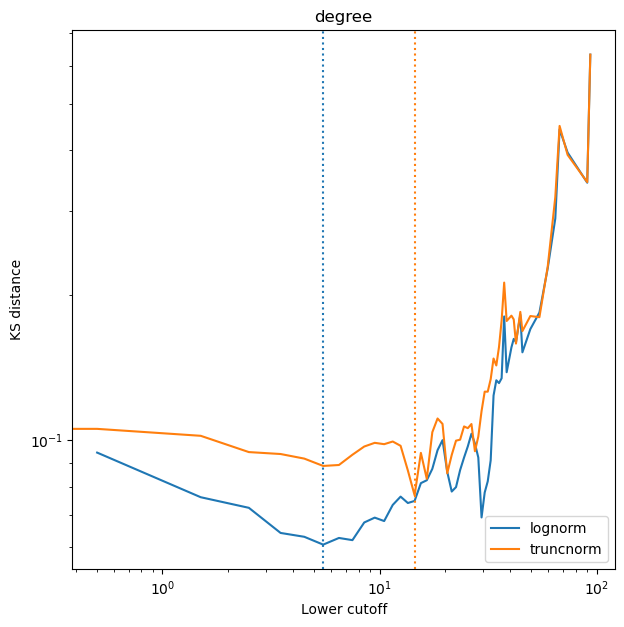

In [7]:
# Find candidate lower cutoffs by minimising KS distance

val_seq, measure = deg_list, 'degree'

# ks_method = 'ave'
ks_method = 'sup'

# model_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
model_list = ['lognorm', 'truncnorm']
num_models = len(model_list)
print('N = ' + str(len(val_seq)) + ', min. = ' + str(min(val_seq)) + ', max. = ' + str(max(val_seq)) + ', mean = ' + str(np.mean(val_seq)))
lower_cutoff_hat_list_0 = [np.nan for i_model in range(num_models)]
lower_cutoff_hat_seq_list = []
ks_seq_list = []
for i_model in range(num_models):
    model = model_list[i_model]
    lower_cutoff_hat, ks, lower_cutoff_hat_seq, ks_seq = fit_lower_cutoff(val_seq, model=model, continuous=False, ks_method=ks_method)
    #ks_nan_pos_list = np.nonzero(np.isnan(ks_seq))[0].tolist()
    #print([i_year, i_model, lower_cutoff_hat, ks_nan_pos_list])
    lower_cutoff_hat_list_0[i_model] = lower_cutoff_hat
    lower_cutoff_hat_seq_list = lower_cutoff_hat_seq_list + [lower_cutoff_hat_seq]
    ks_seq_list = ks_seq_list + [ks_seq]
print('x_min = ' + str(lower_cutoff_hat_list_0))
N_null_list_0 = [len([val for val in val_seq if val >= lower_cutoff_hat]) for lower_cutoff_hat in lower_cutoff_hat_list_0]
print('N = ' + str(N_null_list_0))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
line_list = []
for i_model in range(num_models):
    model = model_list[i_model]
    lower_cutoff_hat_seq = lower_cutoff_hat_seq_list[i_model]
    ks_seq = ks_seq_list[i_model]
    line = ax.errorbar(lower_cutoff_hat_seq, ks_seq, label=model)
    line_list = line_list + [line]
ax.set_xscale('log')
ax.set_yscale('log')
y_lim = list(ax.get_ylim())
for i_model in range(num_models):
    model = model_list[i_model]
    lower_cutoff_hat_seq = lower_cutoff_hat_seq_list[i_model]
    ks_seq = ks_seq_list[i_model]
    ind_min_ks = np.nanargmin(ks_seq)
    lower_cutoff_hat = lower_cutoff_hat_seq[ind_min_ks]
    line = line_list[i_model]
    col = line.lines[0].get_color()
    line = ax.errorbar([lower_cutoff_hat, lower_cutoff_hat], y_lim, linestyle=':', color=col)
ax.set_xlabel('Lower cutoff')
ax.set_ylabel('KS distance')
plt.legend(loc='lower right')
ax.set_ylim(y_lim)
# ax.set_xlim([30, 50]); ax.set_ylim([0.01, 0.04])
ax.set_title(measure)
plt.show()

N = 302, min. = 0, max. = 576, mean = 79.0794701986755


H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:428: RuntimeWarning: divide by zero encountered in log
  param_hat, lp_seq = fit_model(np.log(val_seq), model=model, lower_cutoff_hat=np.log(lower_cutoff_hat), param0=param0)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:428: RuntimeWarning: invalid value encountered in log
  param_hat, lp_seq = fit_model(np.log(val_seq), model=model, lower_cutoff_hat=np.log(lower_cutoff_hat), param0=param0)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:429: RuntimeWarning: divide by zero encountered in log
  lp_seq = lp_seq - np.log(val_seq)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:603: RuntimeWarning: divide by zero encountered in log
  cdf_fun = lambda seq : expon.cdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)
H:\Nutstore\constrained-surrogates\./src\constrained_likelihood_surrogates.py:603: RuntimeWarni

x_min = [11.5, 33.5]
N = [272, 231]


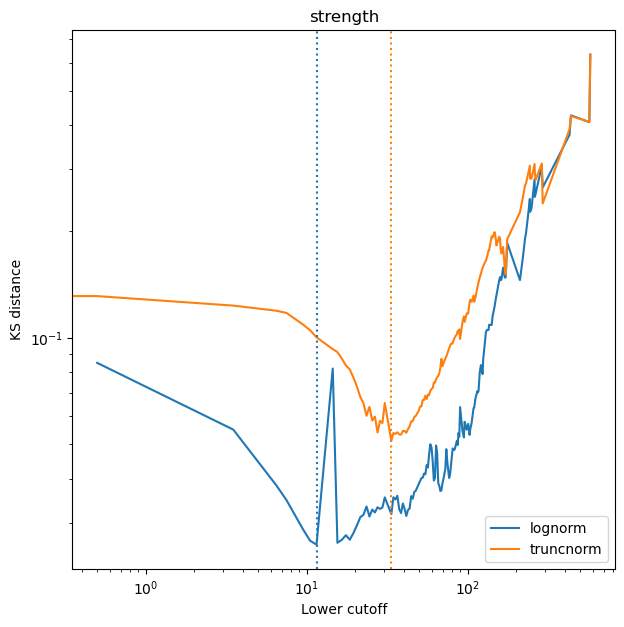

In [8]:
# Find candidate lower cutoffs by minimising KS distance

val_seq, measure = strength_list, 'strength'

# ks_method = 'ave'
ks_method = 'sup'

# model_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
model_list = ['lognorm', 'truncnorm']
num_models = len(model_list)
print('N = ' + str(len(val_seq)) + ', min. = ' + str(min(val_seq)) + ', max. = ' + str(max(val_seq)) + ', mean = ' + str(np.mean(val_seq)))
lower_cutoff_hat_list_0 = [np.nan for i_model in range(num_models)]
lower_cutoff_hat_seq_list = []
ks_seq_list = []
for i_model in range(num_models):
    model = model_list[i_model]
    lower_cutoff_hat, ks, lower_cutoff_hat_seq, ks_seq = fit_lower_cutoff(val_seq, model=model, continuous=False, ks_method=ks_method)
    #ks_nan_pos_list = np.nonzero(np.isnan(ks_seq))[0].tolist()
    #print([i_year, i_model, lower_cutoff_hat, ks_nan_pos_list])
    lower_cutoff_hat_list_0[i_model] = lower_cutoff_hat
    lower_cutoff_hat_seq_list = lower_cutoff_hat_seq_list + [lower_cutoff_hat_seq]
    ks_seq_list = ks_seq_list + [ks_seq]
print('x_min = ' + str(lower_cutoff_hat_list_0))
N_null_list_0 = [len([val for val in val_seq if val >= lower_cutoff_hat]) for lower_cutoff_hat in lower_cutoff_hat_list_0]
print('N = ' + str(N_null_list_0))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
line_list = []
for i_model in range(num_models):
    model = model_list[i_model]
    lower_cutoff_hat_seq = lower_cutoff_hat_seq_list[i_model]
    ks_seq = ks_seq_list[i_model]
    line = ax.errorbar(lower_cutoff_hat_seq, ks_seq, label=model)
    line_list = line_list + [line]
ax.set_xscale('log')
ax.set_yscale('log')
y_lim = list(ax.get_ylim())
for i_model in range(num_models):
    model = model_list[i_model]
    lower_cutoff_hat_seq = lower_cutoff_hat_seq_list[i_model]
    ks_seq = ks_seq_list[i_model]
    ind_min_ks = np.nanargmin(ks_seq)
    lower_cutoff_hat = lower_cutoff_hat_seq[ind_min_ks]
    line = line_list[i_model]
    col = line.lines[0].get_color()
    line = ax.errorbar([lower_cutoff_hat, lower_cutoff_hat], y_lim, linestyle=':', color=col)
ax.set_xlabel('Lower cutoff')
ax.set_ylabel('KS distance')
plt.legend(loc='lower right')
ax.set_ylim(y_lim)
# ax.set_xlim([30, 50]); ax.set_ylim([0.01, 0.04])
ax.set_title(measure)
plt.show()

In [9]:
# Determining REJECTION RATE from constrained and typical surrogates for degree and strength data for hermaphrodite C. elegans connectome
# 
# Use several types of statistics as test statistics
# 
# Considering constrained and typical surrogates
# 
# 
# Model-free statistics:
# free_stat_list = [mean_val, second_mom, third_mom, fourth_mom, max_val, variance, coef_var, dispersion, skew, kurtosis, evi_mom, evi_smooth]
free_stat_list = [mean_val, second_mom, third_mom, fourth_mom, max_val, variance, coef_var, dispersion, skew, kurtosis, evi_mom, evi_smooth, log_mean, log_var, log_skew, log_kurt, jb_stat, log_jb_stat, dap_stat, log_dap_stat]
# free_stat_list = free_stat_list = [mean_val, second_mom, third_mom, fourth_mom, max_val, variance, coef_var, dispersion, skew, kurtosis, evi_mom, evi_smooth, geom_mean, harm_mean, rang, log_rang, iq_rang, log_iq_rang]
num_free_stats = len(free_stat_list)
# Model-dependent statistics (dependent on one model - this characterisation is an excuse so leave out the likelihood ratio):
# depe_stat_list = [ks_stat, ad_stat, cvm_stat]
depe_stat_list = [ks_stat, kuiper_stat, ad_stat, cvm_stat, zk_stat, za_stat, zc_stat]
num_depe_stats = len(depe_stat_list)

model_list = ['lognorm', 'truncnorm']
num_models = len(model_list)

measure_list = ['degree', 'strength']
num_measures = len(measure_list)
measure_seq_list = [deg_list, strength_list]

# lower_cutoff_list = [0.5, 0.5]#Minimum positive observed value - 0.5
lower_cutoff_list = [1.5, 4.5]#Minimum value which avoids obvious deviations
# lower_cutoff_list = [5.5, 11.5]#Value which minimises KS-distance for maximum likelihood lognormal fit

test_type = 'rejection'
for i_measure in range(num_measures):
    start_time = timer()
    measure = measure_list[i_measure]
    measure_seq = measure_seq_list[i_measure]
    
    lower_cutoff = lower_cutoff_list[i_measure]
    
    val_seq_full = [val for val in measure_seq if (val >= lower_cutoff)]
    N_max = len(val_seq_full)#Number of data not less than lower cutoff
    log_N_list = np.linspace(np.log(4), np.log(N_max), 9)
    N_list = np.round(np.exp(log_N_list))
    N_list = [int(N) for N in N_list]
    print('N_list = ' + str(N_list))
    for N in N_list:
        start_time = timer()
        num_trans = N*(int(np.ceil(np.log2(N*1024))))
        
        num_surr = 9
        num_tests = 10**1
        
        a = lower_cutoff
        b = 9
        
        print('N = ' + str(N) + ', lower cut-off = ' + str(lower_cutoff))
        
        print(str(num_tests) + ' tests, each with ' + str(num_surr) + ' constrained, typical surrogates, each using ' + str(num_trans) + ' transitions')
        
        num_methods = 2#Based on constrained, typical
        
        # with warnings.catch_warnings():
        #     warnings.filterwarnings('error', message='invalid value encountered in subtract')
        #     warnings.filterwarnings('error', message='divide by zero encountered in log')
        #     warnings.filterwarnings('error', message='divide by zero encountered in double_scalars')
        #     warnings.filterwarnings('error', message='invalid value encountered in true_divide')
        
        save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
        
        process_str = '_celegans_' + measure
        
        free_quantile_list_list = np.full((num_methods, num_models, num_tests, num_free_stats), np.nan)#Array of nans
        depe_quantile_list_list = np.full((num_methods, num_models, num_tests, num_depe_stats), np.nan)#Array of nans
        
        for i_test in range(num_tests):
            #Generate time series and calculate ks distance:
            val_seq = random.sample(val_seq_full, N)
            lower_cutoff_hat = lower_cutoff
            free_stat_val_list = [stat(val_seq) for stat in free_stat_list]
            for i_model in range(num_models):
                model = model_list[i_model]
                param_hat_m, lp_seq_m = fit_model(val_seq, lower_cutoff_hat=lower_cutoff_hat, model=model)#m for model
                val_seq_sorted = sorted(val_seq)
                emp_cdf_with_rep = rankdata(val_seq_sorted, method='max')/len(val_seq_sorted)
                cdf_fun = return_cdf_func(param_hat_m, model=model, lower_cutoff_hat=lower_cutoff_hat)
                exp_cdf_with_rep = cdf_fun(val_seq_sorted)
                depe_stat_val_list = [stat(exp_cdf_with_rep, emp_cdf_with_rep) for stat in depe_stat_list]
                
                c_surr_m_free_list_list = np.zeros(shape=(num_surr, num_free_stats))#Constrained
                t_surr_m_free_list_list = np.zeros(shape=(num_surr, num_free_stats))#Typical
                
                c_surr_m_depe_list_list = np.zeros(shape=(num_surr, num_depe_stats))#Constrained
                t_surr_m_depe_list_list = np.zeros(shape=(num_surr, num_depe_stats))#Typical
                
                surr_m_val_seq = val_seq
                surr_m_val_seq_list = []
                for i_surr in range(num_surr):
                    method = 'constrained'
                    surr_m_val_seq = gen_surrogate(surr_m_val_seq, model=model, method=method, num_trans=num_trans, lower_cutoff_hat=lower_cutoff_hat, param_hat=param_hat_m)
                    random.shuffle(surr_m_val_seq)
                    surr_m_val_seq_list = surr_m_val_seq_list + [surr_m_val_seq]

                for i_surr in range(num_surr):
                    method = 'constrained'
                    surr_m_val_seq = surr_m_val_seq_list[i_surr]
                    surr_m_param_hat_m, surr_m_lp_seq_m = fit_model(surr_m_val_seq, lower_cutoff_hat=lower_cutoff_hat, model=model)
                    surr_m_free_stat_list_m = [stat(surr_m_val_seq) for stat in free_stat_list]
                    c_surr_m_free_list_list[i_surr, :] = surr_m_free_stat_list_m
                    surr_m_val_seq_sorted = sorted(surr_m_val_seq)
                    emp_cdf_with_rep = rankdata(surr_m_val_seq_sorted, method='max')/len(surr_m_val_seq_sorted)
                    cdf_fun = return_cdf_func(surr_m_param_hat_m, model=model, lower_cutoff_hat=lower_cutoff_hat)
                    exp_cdf_with_rep = cdf_fun(surr_m_val_seq_sorted)
                    surr_m_depe_stat_val_list_m = [stat(exp_cdf_with_rep, emp_cdf_with_rep) for stat in depe_stat_list]
                    c_surr_m_depe_list_list[i_surr, :] = surr_m_depe_stat_val_list_m

                for i_surr in range(num_surr):
                    method = 'typical'
                    surr_m_val_seq = gen_surrogate(val_seq, model=model, method=method, num_trans=num_trans, lower_cutoff_hat=lower_cutoff_hat, param_hat=param_hat_m)
                    surr_m_param_hat_m, surr_m_lp_seq_m = fit_model(surr_m_val_seq, lower_cutoff_hat=lower_cutoff_hat, model=model)
                    surr_m_free_stat_list_m = [stat(surr_m_val_seq) for stat in free_stat_list]
                    t_surr_m_free_list_list[i_surr, :] = surr_m_free_stat_list_m
                    surr_m_val_seq_sorted = sorted(surr_m_val_seq)
                    emp_cdf_with_rep = rankdata(surr_m_val_seq_sorted, method='max')/len(surr_m_val_seq_sorted)
                    cdf_fun = return_cdf_func(surr_m_param_hat_m, model=model, lower_cutoff_hat=lower_cutoff_hat)
                    exp_cdf_with_rep = cdf_fun(surr_m_val_seq_sorted)
                    surr_m_depe_stat_val_list_m = [stat(exp_cdf_with_rep, emp_cdf_with_rep) for stat in depe_stat_list]
                    t_surr_m_depe_list_list[i_surr, :] = surr_m_depe_stat_val_list_m

                for i_free_stat in range(num_free_stats):
                    #Calculate values of discriminating statistic (model-free statistics) for observed sequence and surrogate sequences:
                    obs_stat = free_stat_val_list[i_free_stat]
                    abs_obs_stat = abs(obs_stat)#Add small random perturbations to avoid ties
                    if (abs_obs_stat == np.inf):
                        abs_obs_stat = 0
                    obs_stat = obs_stat + 10**-6*abs_obs_stat*(np.random.uniform() - 0.5)
                    for i_method in range(num_methods):
                        if (i_method == 0):#Constrained surrogates
                            stat_val_surr_m_list = c_surr_m_free_list_list[:, i_free_stat]
                        elif (i_method == 1):#Typical surrogates
                            stat_val_surr_m_list = t_surr_m_free_list_list[:, i_free_stat]
                        stat_val_surr_m_list = stat_val_surr_m_list + 10**-6*abs_obs_stat*(np.random.uniform(size=num_surr) - 0.5)#Add small random perturbations to avoid ties
                        #Work out rank of observed statistic (position of statistic corresponding to observed sequence when statistics corresponding to observed sequence and surrogate sequences are ranked from smallest to largest)
                        rankMin = 1 + sum(stat_val_surr_m_list < obs_stat)
                        rankMax = 1 + sum(stat_val_surr_m_list <= obs_stat)
                        r = random.randint(rankMin, rankMax)
                        q = (r - 0.5)/(num_surr + 1)
                        free_quantile_list_list[i_method, i_model, i_test, i_free_stat] = q
                        if (np.isnan(q)):
                            raise Exception('Calculated quantile q is not a number.')

                for i_depe_stat in range(num_depe_stats):
                    #Calculate values of discriminating statistic (model-dependent statistics) for observed sequence and surrogate sequences:
                    obs_stat = depe_stat_val_list[i_depe_stat]
                    abs_obs_stat = abs(obs_stat)#Add small random perturbations to avoid ties
                    if (abs_obs_stat == np.inf):
                        abs_obs_stat = 0
                    obs_stat = obs_stat + 10**-6*abs_obs_stat*(np.random.uniform() - 0.5)
                    for i_method in range(num_methods):
                        if (i_method == 0):#Constrained surrogates
                            stat_val_surr_m_list = c_surr_m_depe_list_list[:, i_depe_stat]
                        elif (i_method == 1):#Typical surrogates
                            stat_val_surr_m_list = t_surr_m_depe_list_list[:, i_depe_stat]
                        stat_val_surr_m_list = stat_val_surr_m_list + 10**-6*abs_obs_stat*(np.random.uniform(size=num_surr) - 0.5)#Add small random perturbations to avoid ties
                        #Work out rank of observed statistic (position of statistic corresponding to observed sequence when statistics corresponding to observed sequence and surrogate sequences are ranked from smallest to largest)
                        rankMin = 1 + sum(stat_val_surr_m_list < obs_stat)
                        rankMax = 1 + sum(stat_val_surr_m_list <= obs_stat)
                        r = random.randint(rankMin, rankMax)
                        q = (r - 0.5)/(num_surr + 1)
                        depe_quantile_list_list[i_method, i_model, i_test, i_depe_stat] = q
                        if (np.isnan(q)):
                            raise Exception('Calculated quantile q is not a number.')

        end_time = timer()
        total_time = end_time - start_time
        print('N=' + str(N) + ' took ' + str(total_time) + 'sec.') # Time in seconds, e.g. 5.38091952400282

        save_str = save_str_0 + process_str

        free_stat_name_list = [stat.__name__ for stat in free_stat_list]
        depe_stat_name_list = [stat.__name__ for stat in depe_stat_list]

        save_dict = {'free_quantile_list_list':free_quantile_list_list.tolist(),
                     'depe_quantile_list_list':depe_quantile_list_list.tolist(),
                     'test_type':test_type,
                     'lower_cutoff':lower_cutoff,
                     'N':N,
                     'num_trans':num_trans,
                     'num_surr':num_surr,
                     'num_tests':num_tests,
                     'num_methods':num_methods,
                     'process_str':process_str,
                     'model_list':model_list,
                     'save_str':save_str,
                     'total_time':total_time,
                     'free_stat_name_list':free_stat_name_list,
                     'depe_stat_name_list':depe_stat_name_list,
                     'measure_seq':measure_seq,
                     'val_seq_full':val_seq_full,
        }
        
        save('./results/hyp-test/brain/' + save_str, save_dict)

N_list = [4, 7, 12, 20, 33, 57, 97, 165, 280]
N = 4, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 48 transitions
N=4 took 8.6492814000012sec.
N = 7, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 91 transitions
N=7 took 7.826334500001394sec.
N = 12, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 168 transitions
N=12 took 8.182610300000306sec.
N = 20, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 300 transitions
N=20 took 7.949970899999244sec.
N = 33, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 528 transitions
N=33 took 8.83602350000001sec.
N = 57, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 912 transitions
N=57 took 10.610368499999822sec.
N = 97, lower cut-off = 1.5
10 tests, each with 9 constrained, typical surrogates, each using 1649 transitions